In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.models import load_model
import cv2
from tqdm import tqdm
import tqdm as notebook_tqdm
import imutils

2026-03-10 10:42:37.067214: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


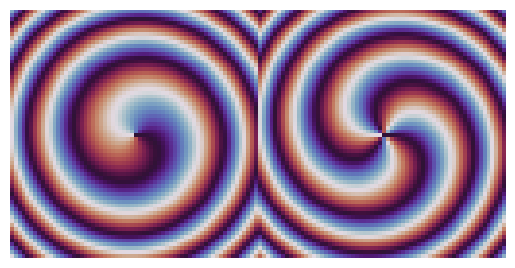

In [2]:
def myfft2(A): 
    return np.fft.fftshift(np.fft.fft2(np.fft.fftshift(A)))

## Vortex map maker
# Topological Charges
m1 = 1 ; m2 = 3

xmax = 10       # f-plane max
dim = 64        # Image Size
dx = 2*xmax/dim # f-plane pixel size

# Get cylindrical coord
x = np.linspace(-xmax,xmax-dx,dim)
X,Y=np.meshgrid(x,x)
R2=(X**2+Y**2)
T = np.arctan2(Y,X)

# Lens Parameters
flambda=80
Lens = np.exp(-1j*R2/(flambda/10))

# Vortex phase modulation
V1 = np.exp(1j*(m1)*T) 
V2 = np.exp(1j*(m2)*T)
LG1=Lens*V1 ; LG2=Lens*V2

# Plot phase to make sure it's the right shape
plt.imshow(np.angle(np.hstack((LG1,LG2))),cmap='twilight')
plt.axis('off')
plt.show()

# This function takes a numpy array of size [num_images, dim, dim]
# and applies a vortex phase, an fft, and an absolute value to each image
def vort_THIS(A,LGA,LGB):
    length=A.shape[0]
    out=np.zeros((length,A.shape[1],A.shape[2]*2))
    for i in range(length):
        A1=np.abs(myfft2(np.exp(1j*A[i]*np.pi/2)*LGA)) ; A2=np.abs(myfft2(np.exp(1j*A[i]*np.pi/2)*LGB))
        # Our single layer NN requires domain restriction within [-1,1]
        A1=(A1-np.amin(A1))/np.amax(A1-np.amin(A1))*2-1    ; A2=(A2-np.amin(A2))/np.amax(A2-np.amin(A2))*2-1
        out[i]=np.hstack((A1,A2))
    return out

In [3]:
from tensorflow.keras.utils import to_categorical

DIM = 64           # Image dimension 
NUM_CLASSES = 4     # Number of tumor categories


def load_and_preprocess_data(data_dir):
    """Loads images as a dataset, converts to NumPy, and gets integer labels."""
    print(f"Loading data from: {data_dir}")

    ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        labels='inferred',
        label_mode='int', # Load as integers
        image_size=(DIM, DIM),
        batch_size=None, # Load all data into one tensor
        shuffle=False
    )
    # Convert to NumPy array
    # x shape will be (N, DIM, DIM, 3)
    x = np.array([item[0].numpy() for item in ds])
    y = np.array([item[1].numpy() for item in ds])
    
    return x, y


# Load preprocessed training and testing data
x_train, y_train = load_and_preprocess_data('/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Brain Tumor Dataset/Training/')
x_test, y_test = load_and_preprocess_data('/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Brain Tumor Dataset/Testing/')

# Number of training and testing samples
n_train, n_test = x_train.shape[0], x_test.shape[0]

print(f"\nTraining Samples: {n_train}, Testing Samples: {n_test}")


def convert_to_grayscale_batch(images_rgb_batch, N_samples):
    """Converts a batch of (N, H, W, 3) images to (N, H, W, 1) grayscale using cv2."""
    # Initialize an empty array for the final grayscale data
    images_gray_batch = np.empty((N_samples, DIM, DIM, 1), dtype=np.float32)

    # Loop through the batch and apply the conversion image-by-image
    for i in tqdm(range(N_samples), desc="Converting to Grayscale"):
        # OpenCV needs uint8 format (0-255)
        image_uint8 = images_rgb_batch[i].astype(np.uint8)
        
        # Perform the conversion (Output is 2D: H x W)
        gray_2d = cv2.cvtColor(image_uint8, cv2.COLOR_RGB2GRAY)
        
        # Add the channel dimension back and store (Shape: H x W x 1)
        images_gray_batch[i] = gray_2d[..., np.newaxis]
        
    return images_gray_batch

# Normalize to [0, 1] range
x_train = convert_to_grayscale_batch(x_train, n_train) / 255.0
x_test = convert_to_grayscale_batch(x_test, n_test) / 255.0


def downsample_batch(images_batch, target_dim):
    """Resizes a batch of images from (N, 256, 256) to (N, target_dim, target_dim)."""
    print(f"Downsampling images from {images_batch.shape[1]}x{images_batch.shape[2]} to {target_dim}x{target_dim}...")
    
    downsampled_images = np.empty((images_batch.shape[0], target_dim, target_dim), dtype=np.float32)
    
    # Loop and resize each image
    for i in tqdm(range(images_batch.shape[0]), desc="Resizing Images"):
        # The INTER_AREA interpolation is best for shrinking images
        downsampled_images[i] = cv2.resize(images_batch[i], 
                                           (target_dim, target_dim), 
                                           interpolation=cv2.INTER_AREA)
    return downsampled_images


DIM = 64  # New dimension after downsampling-

# X_train_vort_input is now (N, 32, 32)
x_train = downsample_batch(x_train, DIM)
x_test = downsample_batch(x_test, DIM)


# Lablels
y_train = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test = to_categorical(y_test, num_classes=NUM_CLASSES)

# Remove the single channel dimension (axis=-1) for the 'vort_THIS' function.
print(x_train.shape, x_test.shape)
#x_train = np.squeeze(x_train, axis=-1)
#x_test = np.squeeze(x_test, axis=-1)

Loading data from: /mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Brain Tumor Dataset/Training/
Found 5712 files belonging to 4 classes.


I0000 00:00:1773164561.193822    1505 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6827 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:01:00.0, compute capability: 8.6
2026-03-10 10:42:54.656312: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Loading data from: /mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Brain Tumor Dataset/Testing/
Found 1311 files belonging to 4 classes.


2026-03-10 10:42:56.693933: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-10 10:42:57.830964: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Training Samples: 5712, Testing Samples: 1311


...

Downsampling images from 64x64 to 64x64...


Resizing Images: 100%|██████████| 5712/5712 [00:00<00:00, 129143.86it/s]


Downsampling images from 64x64 to 64x64...


Resizing Images: 100%|██████████| 1311/1311 [00:00<00:00, 132432.57it/s]

(5712, 64, 64) (1311, 64, 64)


In [4]:
CUSTOM_OBJECTS = {
            # 1. Metrics (Likely Source of Error)
            'keras.metrics.MSE': tf.keras.metrics.MeanSquaredError(),
            'MSE': tf.keras.metrics.MeanSquaredError(),
            'mse': tf.keras.metrics.MeanSquaredError(),
            
            # 2. Loss Functions (Possible Source of Error)
            'mean_squared_error': tf.keras.losses.MeanSquaredError(),
            
            # 3. Optimizers (Needed if you want to resume training, though not needed for prediction)
            'rmsprop': tf.keras.optimizers.RMSprop() 
        }


model_path = f'/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Reconstruction Models/Seed101/64x64/9_speckles.keras'
reconstruction_model = load_model(model_path, custom_objects=CUSTOM_OBJECTS)


In [5]:
transformed_xtrain=vort_THIS(x_train, LG1, LG2)
transformed_xtest=vort_THIS(x_test, LG1, LG2)

In [6]:
N_train = 5712

recon_tumor = reconstruction_model.predict(
    transformed_xtrain.reshape(N_train, 2 * DIM**2)
).reshape(N_train, DIM, DIM)

2026-03-10 10:43:09.852289: I external/local_xla/xla/service/service.cc:163] XLA service 0x7811e8002ff0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-10 10:43:09.852375: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3080, Compute Capability 8.6
2026-03-10 10:43:09.885487: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700
2026-03-10 10:43:10.436916: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4', 60 bytes spill stores, 60 bytes spill loads



 36/179 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

I0000 00:00:1773164590.726841    7114 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


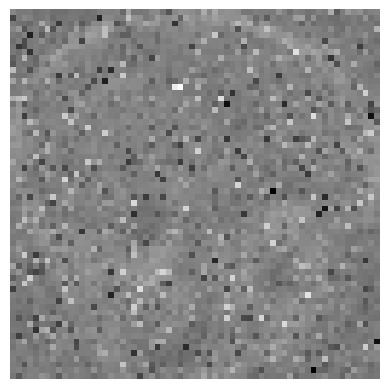

In [8]:
plt.imshow(recon_tumor[1023], cmap='gray')
plt.axis('off')
plt.show()

In [10]:
def calculate_full_dataset_fft_fi(X_train, y_train, epsilon=1e-4):
    y_ints = np.argmax(y_train, axis=1)
    
    # 1. Get the "Anchor": The Average Healthy Brain (Class 2)
    healthy_images = X_train[y_ints == 2]
    # Ensure 64x64 and take the Magnitude of the 2D FFT
    healthy_mean = np.mean(healthy_images, axis=0).reshape(64, 64)
    fft_healthy = np.abs(np.fft.fft2(healthy_mean))

    # 2. Storage for FFT FI scores
    fft_fi_scores = {c: [] for c in range(4)}

    for i in range(len(X_train)):
        img = X_train[i].reshape(64, 64)
        label = y_ints[i]
        
        # 2D FFT Magnitude of the individual image
        fft_img = np.abs(np.fft.fft2(img))
        
        # FI = sum( (FFT_Img - FFT_Healthy_Mean)^2 / (FFT_Img + epsilon) )
        # Summed over all N=4096 frequency bins
        numerator = (fft_img - fft_healthy)**2
        denominator = fft_img + epsilon
        total_fi = np.sum(numerator / denominator)
        
        fft_fi_scores[label].append(total_fi)

    # 3. Calculate Stats
    stats = {}
    class_names = {0: 'Glioma', 1: 'Meningioma', 2: 'No_Tumor', 3: 'Pituitary'}
    for c, scores in fft_fi_scores.items():
        stats[class_names[c]] = {
            'Mean_FFT_FI': np.mean(scores),
            'Std_FFT_FI': np.std(scores)
        }
    
    return stats

FI_FFT = calculate_full_dataset_fft_fi(recon_tumor, y_train)
print(FI_FFT)

{'Glioma': {'Mean_FFT_FI': np.float32(3994.1711), 'Std_FFT_FI': np.float32(2253.1033)}, 'Meningioma': {'Mean_FFT_FI': np.float32(4681.826), 'Std_FFT_FI': np.float32(1266.9955)}, 'No_Tumor': {'Mean_FFT_FI': np.float32(5892.272), 'Std_FFT_FI': np.float32(2698.9456)}, 'Pituitary': {'Mean_FFT_FI': np.float32(4234.48), 'Std_FFT_FI': np.float32(979.9308)}}


In [11]:
CV_FFT_0 = FI_FFT['Glioma']['Std_FFT_FI'] / FI_FFT['Glioma']['Mean_FFT_FI']
CV_FFT_1 = FI_FFT['Meningioma']['Std_FFT_FI'] / FI_FFT['Meningioma']['Mean_FFT_FI']
CV_FFT_2 = FI_FFT['No_Tumor']['Std_FFT_FI'] / FI_FFT['No_Tumor']['Mean_FFT_FI']
CV_FFT_3 = FI_FFT['Pituitary']['Std_FFT_FI'] / FI_FFT['Pituitary']['Mean_FFT_FI']

print(f"\nCoefficient of Variation (CV) for FFT FI:")
print(f"  Class 0: {CV_FFT_0:.4f}")
print(f"  Class 1: {CV_FFT_1:.4f}")
print(f"  Class 2: {CV_FFT_2:.4f}")
print(f"  Class 3: {CV_FFT_3:.4f}")


Coefficient of Variation (CV) for FFT FI:
  Class 0: 0.5641
  Class 1: 0.2706
  Class 2: 0.4580
  Class 3: 0.2314


In [12]:
def generate_fi_heatmaps_fft(X_train, y_train, epsilon=1e-4):
    y_ints = np.argmax(y_train, axis=1)
    class_names = {0: 'Glioma', 1: 'Meningioma', 2: 'No_Tumor', 3: 'Pituitary'}
    
    # 1. Create the "Anchor" (Average Healthy Brain)
    healthy_images = X_train[y_ints == 2]
    healthy_mean = np.mean(healthy_images, axis=0).reshape(64, 64)
    fft_healthy = np.abs(np.fft.fft2(healthy_mean))

    # 2. Storage for the 64x64 matrices
    fi_matrices = {c: [] for c in range(4)}

    for i in range(len(X_train)):
        img = X_train[i].reshape(64, 64)
        label = y_ints[i]
        
        # 2D FFT Magnitude
        fft_img = np.abs(np.fft.fft2(img))
        
        # Calculate Local FI Matrix (Do NOT sum yet)
        numerator = (fft_img - fft_healthy)**2
        denominator = fft_img + epsilon
        local_fi_matrix = numerator / denominator # Result is 64x64
        
        fi_matrices[label].append(local_fi_matrix)

    # 3. Average the matrices per class to get the "Mean FI Map"
    mean_heatmaps = {}
    for c, matrices in fi_matrices.items():
        # Stack and average across the sample dimension
        mean_heatmaps[class_names[c]] = np.mean(matrices, axis=0)
    
    return mean_heatmaps

# Execute
fi_maps_fft = generate_fi_heatmaps_fft(recon_tumor, y_train)

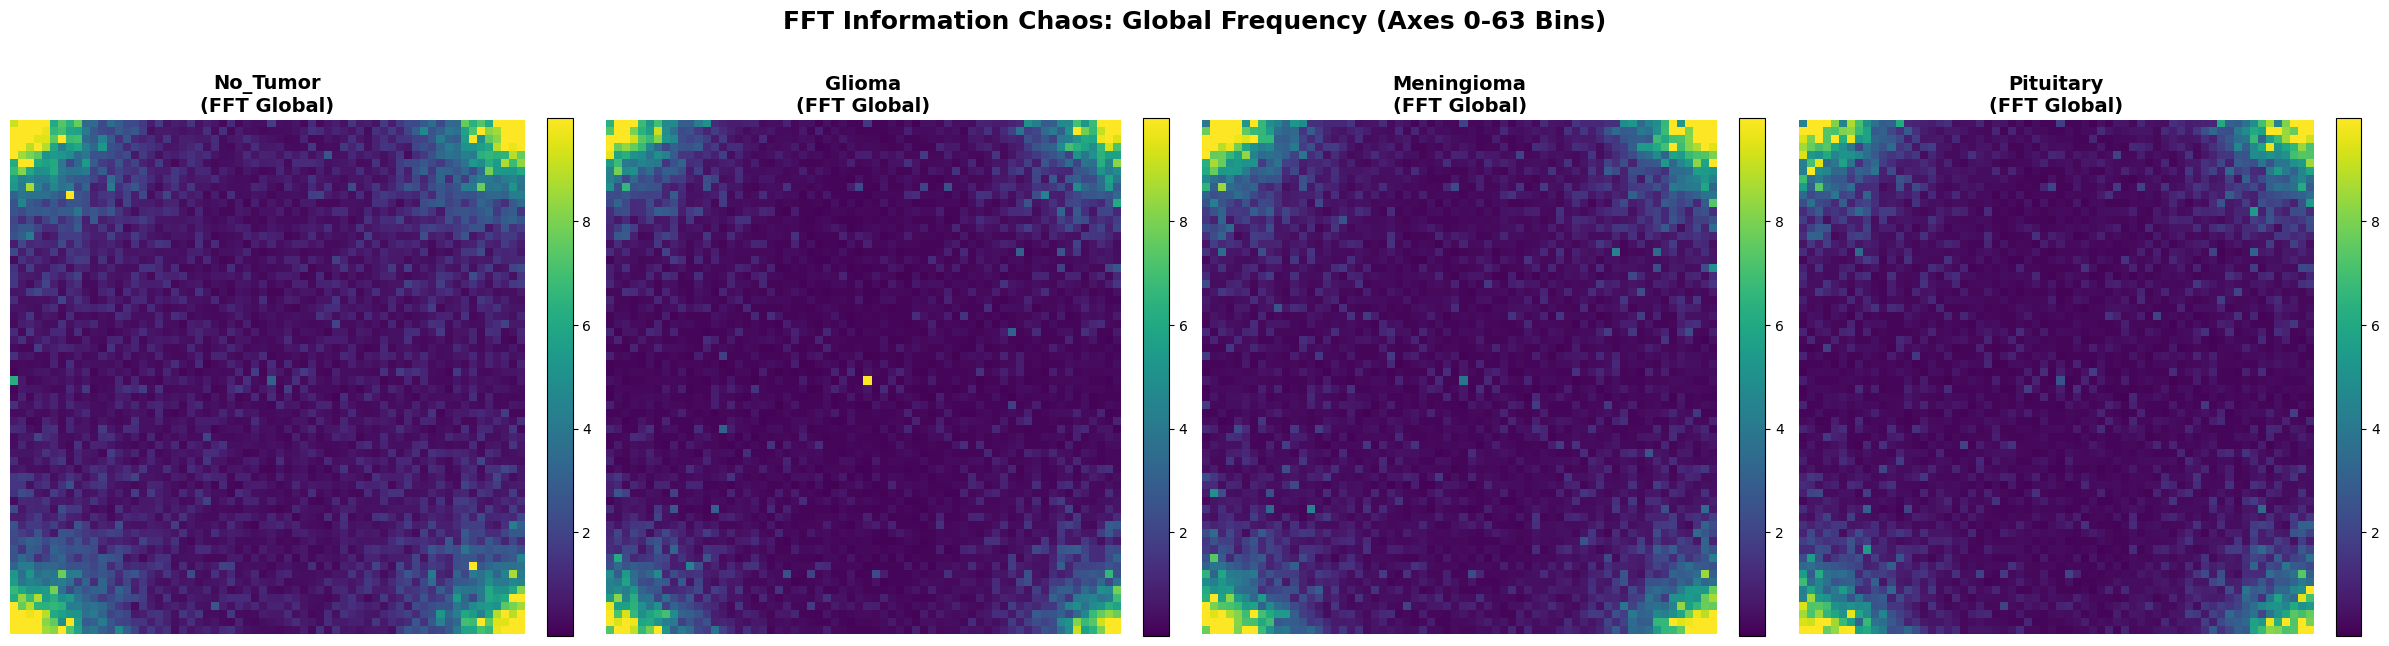

In [14]:
# 4x1 Subplot for FFT (The "Frequency" Map)
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
order = ['No_Tumor', 'Glioma', 'Meningioma', 'Pituitary']
all_values = np.concatenate([fi_maps_fft[cls].flatten() for cls in order])
global_vmax = np.percentile(all_values, 99)

for i, cls in enumerate(order):
    v_max = np.percentile(fi_maps_fft[cls], 99)
    
    im = axes[i].imshow(fi_maps_fft[cls], cmap='viridis', vmin=1e-5, vmax=global_vmax)
    
    axes[i].set_title(f'{cls}\n(FFT Global)', fontsize=14, fontweight='bold')
    axes[i].axis('off')
    
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.suptitle('FFT Information Chaos: Global Frequency (Axes 0-63 Bins)', fontsize=18, y=1.08, fontweight='bold')
plt.tight_layout()
plt.savefig('fft_fi_4x1.png', dpi=300, bbox_inches='tight')
plt.show()